# Chapter 13 — Microstructure and Execution

Ch12 closed the cost cycle on the QQQ closing-window MR strategy with an **after-cost Sharpe of −2.97** at the cost-aware `k_σ*` = 2.20. The spread + commission + impact wedge — about **1.62 bp round-trip** at a $30k notional trade — was several times the per-trade mean PnL (≈ 0.46 bp at `k_σ` = 2.20). The strategy is unprofitable at every threshold; capacity *Q\** = $0.

Ch12 raised one specific rescue hypothesis and closed without testing it: posting **passive limit orders** on entry instead of market orders. A market order *pays* the half-spread; a passive limit, when it fills, *earns* the half-spread. On QQQ that's a swing of about 1.448 bp round-trip — almost the entire cost wedge. If passive entries can be made to fill reliably, the strategy might survive.

This chapter tests that hypothesis honestly. The expected punchline is the canonical microstructure result: **adverse selection eats the spread credit**. Passive limits fill exactly when the market is moving against the posted side, which is precisely when filling is *worst* for the strategy. The chapter measures whether that happens here.

## Three things this chapter covers

1. **Order types are policy choices.** §2.
2. **Passive fills are adversely selected.** §3-§4.
3. **Latency is an implicit cost.** §5.

## §1 — The rescue hypothesis

The Ch12 §2 reframing: Roll's half-spread on QQQ 1-min closes is `s ≈ 0.724 bp`, and Roll's is derived from the *same* lag-1 negative autocovariance that drives Ch7's MR signal. A material chunk of the −0.028 lag-1 ρ in Ch7 is bid-ask bounce, not economic mean-reversion. The strategy was, in part, trying to fade its own counterparty's spread — a structural mismatch, because the strategy must pay the spread to capture the bounce.

The rescue hypothesis flips the sign on the structural mismatch:

- **Buy signal** → post a buy limit at `signal_close − s`. If the limit fills, the entry price is below the signal close by exactly the half-spread; the strategy *receives* `s` instead of paying it.
- **Sell signal** → post a sell limit at `signal_close + s`. Symmetric.

If every signal filled, the round-trip swing would be **+1.448 bp** — almost identical in magnitude to the Ch12 cost wedge that killed the strategy. Combined with rebate income on the maker leg, the rescue looks like it should comfortably flip the sign of the Sharpe.

The chapter tests whether it does.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CACHE = Path('../06-bridge-to-intraday/data')
qqq = pd.read_parquet(CACHE / 'qqq_1min.parquet')
# Localize to NY time; carve out RTH minutes (9:30-15:59 inclusive of 9:30, exclusive of 16:00)
qqq.index = pd.to_datetime(qqq.index, utc=True).tz_convert('America/New_York')
qqq['minute_of_day'] = qqq.index.hour * 60 + qqq.index.minute
RTH_OPEN, RTH_CLOSE = 9*60+30, 16*60
rth = qqq[(qqq['minute_of_day'] >= RTH_OPEN) & (qqq['minute_of_day'] < RTH_CLOSE)].copy()
rth['minute_of_session'] = rth['minute_of_day'] - RTH_OPEN
rth['session_date'] = rth.index.normalize()
# Per-bar log return; drop the first bar of each session (overnight gap)
rth['log_ret'] = np.log(rth['close'] / rth['close'].shift(1))
sf = rth.groupby('session_date').head(1).index
rth.loc[sf, 'log_ret'] = np.nan
print(f'Sessions: {rth["session_date"].nunique()}  Bars: {len(rth):,}')

# Ch12 handoff: Roll's half-spread = 0.724 bp = 7.24e-5 in log-return units
ROLL_S = 7.24e-5
K_SIGMA = 2.20  # Ch12 cost-aware k*
N, K = 1, 3
print(f'ROLL_S = {ROLL_S*1e4:.3f} bp   K_SIGMA = {K_SIGMA}   N={N}  K={K}')

Sessions: 251  Bars: 95,318
ROLL_S = 0.724 bp   K_SIGMA = 2.2   N=1  K=3


## §2 — Order types: a short tour

| Order type | What it does | Maker/taker | Fill certainty |
|---|---|---|---|
| **Market** | Buy/sell now at the best available price. | Taker | Near-guaranteed |
| **Limit** | Buy at `≤ p`; sell at `≥ p`. | Maker (if posted away from the touch) | Conditional |
| **Marketable limit** | A limit with price already at-or-through the touch. | Taker | Near-guaranteed |
| **IOC** | Fill what's available right now; cancel the rest. | Maker on filled portion. | Partial |
| **FOK** | All-or-nothing instant fill. | Maker if filled. | Binary |
| **Hidden** | Limit price + size not displayed. | Maker. | Conditional |
| **Pegged** | Limit price tracks the bid/offer at some offset. | Maker. | Conditional |

### Maker / taker economics

Exchanges charge takers (≈ $0.0030/share) and pay makers (≈ $0.0020-$0.0030/share). On QQQ at ≈ $695, the maker rebate is **0.043 bp/leg** — small but non-zero.

### Payment for order flow (PFOF)

A retail "market order" through Schwab/Robinhood is typically routed to a wholesale market maker (Citadel, Virtu) who fills it at-or-better than NBBO in exchange for paying the broker for the flow. The price improvement is real but smaller than the spread the wholesaler captures.

## §3 — The limit-order simulation

**Fill rule.** A passive entry posted at the signal bar's close fills if a *subsequent* bar within the K-bar hold window prints at-or-through the limit:

- **Buy limit** at `signal_close − s` fills the first time any later bar's `low ≤ signal_close − s`.
- **Sell limit** at `signal_close + s` fills the first time any later bar's `high ≥ signal_close + s`.

If neither condition is met within K bars, the limit *expires unfilled*. Unfilled signals are recorded along with the K-bar post-signal drift in strategy direction — they are the central data for the §4 toxicity diagnostic.

**Exit rule.** Unchanged from Ch12: market-on-open at bar `entry + K`. The exit is still a market order — it pays the half-spread, commission, and impact.

**Limit-price choice — at-the-touch.** Posting at `signal_close − s` means the buy limit sits *at* the implied bid (the favorable side of the touch). This is the most aggressive passive entry; Exercise 1 explores variants.

In [2]:
# Pre-compute per-session signal-window prior returns for the rolling σ estimate.
# The signal window is minutes 360-389 of session (Ch7 closing window, last 30 min).
def precompute_priors(rth_df):
    priors = {}
    dates = sorted(rth_df['session_date'].unique())
    for date in dates:
        day = rth_df[rth_df['session_date'] == date].sort_index().reset_index()
        pts = []
        for i in range(N, len(day)):
            if 360 <= day.loc[i, 'minute_of_session'] < 390 - K:
                pts.append(np.log(day.loc[i, 'close'] / day.loc[i-N, 'close']))
        priors[date] = np.array(pts)
    return priors, dates

priors_by_session, dates_sorted = precompute_priors(rth)

def backtest(rth_df, entry_mode='market', limit_offset=ROLL_S, lookback=20):
    """Event-driven backtest with market or limit entries; K-bar hold.
    Returns a trade ledger with: filled flag, pnl_log, and (for unfilled-limit
    rows) drift_K_unconditional — the post-signal drift in strategy direction.
    """
    trades = []
    for date_idx, date in enumerate(dates_sorted):
        if date_idx < lookback:  # need σ history
            continue
        # Trailing 20-session pool of prior N-bar returns → today's σ threshold
        history = np.concatenate([priors_by_session[d]
                                  for d in dates_sorted[date_idx-lookback:date_idx]])
        thresh = K_SIGMA * history.std() if len(history) > 0 else None
        if thresh is None:
            continue
        day = rth_df[rth_df['session_date'] == date].sort_index().reset_index()
        in_pos, entry_i, entry_px = 0, None, None
        pending_limit, pending_sig, pending_signal_i = None, 0, None
        for i in range(len(day)):
            mos = day.loc[i, 'minute_of_session']
            # Pending limit: check this bar's H/L for a touch
            if pending_limit is not None and i > pending_signal_i:
                bar_high = day.loc[i, 'high']
                bar_low = day.loc[i, 'low']
                if pending_sig == +1 and bar_low <= pending_limit:
                    in_pos, entry_i, entry_px = +1, i, pending_limit
                    pending_limit = None
                elif pending_sig == -1 and bar_high >= pending_limit:
                    in_pos, entry_i, entry_px = -1, i, pending_limit
                    pending_limit = None
                elif i - pending_signal_i >= K:
                    # Limit expired — record an unfilled row with the K-bar drift
                    # in strategy direction for the toxicity diagnostic.
                    sig_i = pending_signal_i
                    end_i = min(sig_i + K, len(day) - 1)
                    drift_uncond = np.log(day.loc[end_i, 'close'] /
                                          day.loc[sig_i, 'close']) * pending_sig
                    trades.append({'date': date, 'filled': False, 'pnl_log': 0.0,
                                   'drift_K_unconditional': drift_uncond})
                    pending_limit, pending_sig, pending_signal_i = None, 0, None
            # Time-stop exit at K bars after entry (market on next bar's open)
            if in_pos != 0 and (i - entry_i) >= K:
                exit_i = min(i + 1, len(day) - 1)
                exit_px = day.loc[exit_i, 'open']
                pnl = in_pos * np.log(exit_px / entry_px)
                trades.append({'date': date, 'filled': True, 'pnl_log': pnl})
                in_pos, entry_i, entry_px = 0, None, None
            # Signal detection (Ch7 window, in_pos and pending checks)
            if in_pos == 0 and pending_limit is None and \
               360 <= mos < 390 - K and i >= N:
                prior_N = np.log(day.loc[i, 'close'] / day.loc[i-N, 'close'])
                if abs(prior_N) > thresh:
                    # MR: buy after downward overshoot, sell after upward
                    sig = -1 if prior_N > 0 else +1
                    if entry_mode == 'market':
                        enxt = min(i + 1, len(day) - 1)
                        in_pos, entry_i, entry_px = sig, i, day.loc[enxt, 'open']
                    else:
                        # Buy below signal close; sell above
                        pending_limit = day.loc[i, 'close'] - sig * limit_offset
                        pending_sig, pending_signal_i = sig, i
    return pd.DataFrame(trades)

In [3]:
# Market-order baseline (Ch12 cost-aware k*, pre-cost)
tr_market = backtest(rth, entry_mode='market')
# Passive limit at-the-touch
tr_limit = backtest(rth, entry_mode='limit', limit_offset=ROLL_S)
filled = tr_limit[tr_limit['filled']].copy()
unfilled = tr_limit[~tr_limit['filled']].copy()
fill_rate = len(filled) / max(len(tr_limit), 1)

def annualize_sharpe(pnl_series, n_trades, n_sessions):
    if n_trades < 2 or pnl_series.std() == 0:
        return float('nan')
    tpy = n_trades / max(n_sessions, 1) * 252  # trades/year scaling
    return (pnl_series.mean() / pnl_series.std()) * np.sqrt(tpy)

sessions_total = tr_market['date'].nunique()
sessions_filled = filled['date'].nunique()
s_market = annualize_sharpe(tr_market['pnl_log'], len(tr_market), sessions_total)
s_limit_filled = annualize_sharpe(filled['pnl_log'], len(filled), sessions_filled)

print(f'Market signals:  {len(tr_market):3d}  mean={tr_market["pnl_log"].mean()*1e4:+.3f} bp  Sharpe={s_market:+.3f}')
print(f'Limit signals:   {len(tr_limit):3d}  filled={len(filled)}  unfilled={len(unfilled)}  fill_rate={fill_rate:.3f}')
print(f'  Filled-only:   mean={filled["pnl_log"].mean()*1e4:+.3f} bp  Sharpe={s_limit_filled:+.3f}  (pre-toxicity)')

Market signals:  200  mean=+0.461 bp  Sharpe=+1.183
Limit signals:   176  filled=157  unfilled=19  fill_rate=0.892
  Filled-only:   mean=+0.288 bp  Sharpe=+0.583  (pre-toxicity)


**Empirical result:** Fill rate **89.2%** (157 / 176). Filled-only pre-cost Sharpe **+0.583** — a +3.5-point swing from Ch12's market-order after-cost Sharpe of −2.97. **The rescue looks like it works.** §4 explains why this number is a lie.

## §4 — The adverse-selection diagnostic

A passive buy limit posted at the bid fills when sellers cross the spread to hit the bid. Some of those sellers are uninformed; some are *informed* — they're selling because they know something the passive buyer doesn't. The passive buyer just bought the top of a move down.

This is **adverse selection**. Fills are not a random sample of signals — fills are conditioned on a counterparty being willing to *cross* the spread at that exact moment, and that crossing decision is itself information.

> **Formula — toxicity diagnostic.**
>
> toxicity = drift<sub>unconditional</sub> − drift<sub>filled</sub>
>
> where:
> - drift<sub>unconditional</sub> = mean over all signal bars of the K-bar log-return in strategy direction (= mean PnL of the matched market-order backtest)
> - drift<sub>filled</sub> = mean over filled passive trades of the K-bar log-return in strategy direction
> - both in log-return units; ×1e4 for bp
>
> **Sign convention.** Positive toxicity → filled trades did *worse* than the unconditional signal set.

In [4]:
drift_unc_bp = tr_market['pnl_log'].mean() * 1e4
drift_filled_bp = filled['pnl_log'].mean() * 1e4
toxicity_bp = drift_unc_bp - drift_filled_bp
drift_unfilled_bp = unfilled['drift_K_unconditional'].mean() * 1e4

print(f'drift_unconditional (all market-order signals): {drift_unc_bp:+.4f} bp')
print(f'drift_filled        (limit fills only):         {drift_filled_bp:+.4f} bp')
print(f'toxicity = unc − filled:                        {toxicity_bp:+.4f} bp')
print(f'drift on UNFILLED signals (strategy dir):       {drift_unfilled_bp:+.4f} bp')

# Cost stack from Ch12: half-spread = 0.724 bp/leg; commission = 0.072 bp/leg;
# impact (consolidated ADV at $30k) = 0.014 bp/leg. Entry leg pays NO spread (it IS
# the passive fill). Exit leg crosses at next bar's open → pays one half-spread + comm + impact.
HALF_SPREAD_BP = 0.724
COMM_RT_BP = 0.144  # 2 × 0.072
IMPACT_RT_BP = 0.029  # 2 × 0.014 at consolidated ADV (Ch12)
exit_leg_cost_bp = HALF_SPREAD_BP + IMPACT_RT_BP/2 + COMM_RT_BP/2
# (Entry-leg commission still applies; we charge it on the entry side too.)
filled['pnl_net_log'] = filled['pnl_log'] - (exit_leg_cost_bp + COMM_RT_BP/2) / 1e4
s_limit_post = annualize_sharpe(filled['pnl_net_log'], len(filled), sessions_filled)
print(f'\nSharpe (limit, post-toxicity, net of exit spread + commission): {s_limit_post:+.3f}')

drift_unconditional (all market-order signals): +0.4612 bp
drift_filled        (limit fills only):         +0.2882 bp
toxicity = unc − filled:                        +0.1730 bp
drift on UNFILLED signals (strategy dir):       +8.1060 bp

Sharpe (limit, post-toxicity, net of exit spread + commission): -1.202


**Two findings.**

1. **Toxicity is small (+0.17 bp).** The filled subset is only slightly worse than the unconditional universe.
2. **The unfilled-bucket drift is enormous (+8.1 bp).** The 19 signals that didn't fill had over 8 bp of drift in strategy direction. The biggest winners self-cancelled.

**Re-priced with the exit-leg cost stack:** the +0.58 pre-toxicity Sharpe drops to **−1.20** — the rescue narrowed the gap from −2.97, but the exit leg still pays the wedge.

## §5 — Latency

> **Definition — signal-to-fill latency.** Wall-clock time between the signal logic emitting an order and the exchange matching engine processing it.

| Setup | Typical latency |
|---|---|
| Co-located HFT | < 1 ms |
| Cloud-hosted retail bot | 5–50 ms |
| Retail desktop on home internet | 50–500 ms |

> **Formula — random-walk latency drift.**
>
> σ<sub>drift</sub> = σ<sub>1min</sub> · √(Δt / 60 s)
>
> where:
> - σ<sub>1min</sub> = per-minute log-return standard deviation
> - Δt = latency in seconds; 60 s = reference bar duration
> - E\|drift\| under normal model ≈ 0.80 σ<sub>drift</sub>

Critically, σ<sub>drift</sub> in *absolute* bp depends only on latency. What changes with bar resolution is the *ratio* to the bar's own σ.

In [5]:
sigma_per_min_bp = rth['log_ret'].std() * 1e4  # QQQ per-bar (1-min) σ in bp
print(f'QQQ 1-min σ: {sigma_per_min_bp:.3f} bp')

rows = []
for bar_s, lat_ms in [(60, 100), (60, 500), (15, 200), (5, 200), (1, 200)]:
    # σ over the latency window — note: depends only on lat_ms, not bar_s
    sigma_drift_bp = sigma_per_min_bp * np.sqrt((lat_ms/1000) / 60)
    e_abs_drift_bp = sigma_drift_bp * np.sqrt(2 / np.pi)  # E|N(0,σ)| = σ√(2/π)
    sigma_bar_bp = sigma_per_min_bp * np.sqrt(bar_s / 60)  # σ at this bar resolution
    rows.append({'bar': f'{bar_s}s', 'latency_ms': lat_ms,
                 'σ_drift_bp': round(sigma_drift_bp, 4),
                 'E|drift|_bp': round(e_abs_drift_bp, 4),
                 'drift_σ / bar_σ': round(sigma_drift_bp / sigma_bar_bp, 3)})
lat_table = pd.DataFrame(rows)
print(lat_table.to_string(index=False))

QQQ 1-min σ: 4.312 bp
bar  latency_ms  σ_drift_bp  E|drift|_bp  drift_σ / bar_σ
60s         100      0.1760       0.1405            0.041
60s         500      0.3936       0.3141            0.091
15s         200      0.2489       0.1986            0.115
 5s         200      0.2489       0.1986            0.200
 1s         200      0.2489       0.1986            0.447


**At 1-min/100ms latency drift is 4% of bar σ — invisible. At 1-sec/200ms it's 45% — dominant.** The Ch6/Ch8 1-min bar choice was implicitly a latency-budget choice.

## §6 — Maker rebates and the realistic verdict

NASDAQ tier-1 maker rebate ≈ **$0.0030/share**. At QQQ ≈ $694.93, that's **0.043 bp per maker leg**.

In [6]:
QQQ_PX = float(rth['close'].iloc[-1])
rebate_bp_per_leg = 0.0030 / QQQ_PX * 1e4
print(f'QQQ ref px: ${QQQ_PX:.2f}   rebate: {rebate_bp_per_leg:.4f} bp/leg')

filled['pnl_rebate_log'] = filled['pnl_net_log'] + rebate_bp_per_leg / 1e4
s_limit_rebate = annualize_sharpe(filled['pnl_rebate_log'], len(filled), sessions_filled)
print(f'Sharpe (limit, post-toxicity + maker rebate): {s_limit_rebate:+.3f}')

QQQ ref px: $694.93   rebate: 0.0432 bp/leg
Sharpe (limit, post-toxicity + maker rebate): -1.114


### The deflation arc, closed

| Stage | Sharpe | Notes |
|---|---:|---|
| Ch8 vectorized in-sample (no costs, snooped) | +2.08 | Ch8 §6 |
| Ch11 walk-forward OOS (no costs) | **+0.88** | Ch11 §7; CI = (−1.6, +3.5) |
| Ch12 cost-aware k\*, market orders, after-cost | **−2.97** | Ch12 §6 |
| **Ch13 passive entry, filled-only, pre-toxicity, pre-cost** | **+0.58** | Apparent rescue |
| **Ch13 passive entry, filled-only, post-toxicity (net exit + commission)** | **−1.20** | Actual realized |
| **Ch13 passive entry, filled-only, post-toxicity + maker rebate** | **−1.11** | Final |

**The execution arc:** +0.88 → −2.97 → −1.11. Passive execution **narrows the loss by ~1.9 Sharpe points** vs market orders — a real improvement worth quantifying. But it does not cross zero. The exit leg still crosses, and the 8.1 bp unfilled-drift means the strategy's biggest winners disappear from the filled ledger.

**Decision rule from the arc:** rebates and passive execution matter when the strategy already has slim-positive expectancy on its own. They don't rescue a structurally cost-dominated strategy.

## §7 — So what?

1. **Passive execution is a tool, not a cure.** Helps when (a) the strategy is cost-dominated, (b) signal has low adverse-selection sensitivity, *and* (c) both legs can be passive. Ch7 MR has (a) and (b) on QQQ but cannot satisfy (c) with a time-stop.
2. **Diagnose toxicity before celebrating the spread credit.**
3. **Watch the unfilled bucket.** Strict toxicity (0.17 bp) is one read; the unfilled-signal drift (+8.1 bp) is often larger.
4. **Match latency to bar resolution.** 1-min/100ms is fine; 1-sec/200ms is not.
5. **Rebates are a tiebreaker, not a strategy.**

## Key Terms

| Term | Definition |
|---|---|
| Market order | Immediate execution at the best available price; taker; pays the spread. |
| Limit order | Execute only at price *p* or better; maker (if posted away from the touch); conditional fill. |
| IOC | Fill what's available now and cancel any rest; prevents leakage. |
| FOK | Fill in full or cancel entirely. |
| Maker | Liquidity provider; earns the maker rebate. |
| Taker | Liquidity remover; pays the taker fee. |
| PFOF | Routing of retail orders to wholesalers for payment; enables zero-commission retail. |
| Fill rate | Filled passive trades / total signals. |
| Adverse selection / toxicity | `drift_unconditional − drift_filled`; how much worse passive fills are than the full signal universe. |
| Latency | Signal-to-fill wall-clock time; random-walk drift = σ<sub>1min</sub> · √(Δt/60). |
| Maker rebate | Per-share credit paid to the maker. NASDAQ tier-1 ≈ $0.0030/share ≈ 0.043 bp/leg on QQQ. |

## Up next

**Ch14 — Position sizing and risk of ruin.** With the after-execution expectancy in hand (here: negative), Kelly tells us how much capital to deploy per trade. Using the pre-cost Sharpe of +0.88 would have us deploying meaningful capital on a strategy that loses money in practice. The Ch12-Ch13 deflation chain is the input that makes Ch14 honest.

## Exercises

1. **Fill-rule strictness.** Re-run the §3 backtest under three fill rules:
   (a) any later bar within K touches the limit (used in the chapter),
   (b) only the *next bar's open* may touch,
   (c) a bar must *trade through* the limit by ε ticks ($0.01 say).
   Compute fill rate, drift_filled, and toxicity under each. Does the +0.17 bp toxicity result survive rule (c)? Which rule is the most realistic for a retail simulator, and why?

2. **Latency sensitivity sweep.** For QQQ at 1-min, 15-sec (resampled), and 5-sec resolutions, compute σ<sub>drift</sub> and E\|drift\| under 100 ms and 500 ms latency assumptions. At what bar resolution does the latency drift exceed the 0.72 bp half-spread credit? *Hint:* you don't need new data; σ<sub>1min</sub> and the √(Δt/60) formula are sufficient.

3. **Maker-rebate breakeven.** Hold fill rate (0.89) and toxicity (0.17 bp) constant. What per-trade gross PnL (in bp) would the strategy need before the 0.043 bp/leg maker rebate is the *deciding* factor between losing and breaking even on after-cost Sharpe? Express the answer in terms of fill rate, gross per-trade std, and the exit-leg cost stack from Ch12.

### Worked solutions

Try the exercises yourself first; the solved cells below are for comparison.

In [7]:
# Exercise 1: Fill-rule strictness.
# Re-run the §3 passive-limit backtest under three increasingly strict fill rules
# and measure how fill rate, drift_filled, and toxicity move. The three rules:
#   (a) any_touch  — any later bar's H/L touches the limit (chapter default; lenient)
#   (b) next_open  — only the FIRST bar AFTER the signal may fill, at its open
#   (c) through_eps — a bar must TRADE THROUGH the limit by eps_ticks ($0.01)
# In a retail simulator the right rule is the strictest one your data supports;
# any_touch is a known overstatement.

# Extend the §3 backtest function with a fill_rule argument. Stub the new
# function inline so this cell is self-contained.
def backtest_with_rule(rth_df, fill_rule="any_touch", eps_dollars=0.01,
                       limit_offset=ROLL_S, lookback=20):
    """fill_rule in {any_touch, next_open, through_eps}; eps_dollars in $."""
    trades = []
    for date_idx, date in enumerate(dates_sorted):
        if date_idx < lookback:
            continue
        history = np.concatenate([priors_by_session[d]
                                  for d in dates_sorted[date_idx - lookback:date_idx]])
        thresh = K_SIGMA * history.std() if len(history) > 0 else None
        if thresh is None:
            continue
        day = rth_df[rth_df["session_date"] == date].sort_index().reset_index()
        in_pos, entry_i, entry_px = 0, None, None
        pending_limit, pending_sig, pending_signal_i = None, 0, None
        for i in range(len(day)):
            mos = day.loc[i, "minute_of_session"]
            if pending_limit is not None and i > pending_signal_i:
                bar_high = day.loc[i, "high"]
                bar_low  = day.loc[i, "low"]
                bar_open = day.loc[i, "open"]
                filled_this = False
                if fill_rule == "any_touch":
                    if pending_sig == +1 and bar_low <= pending_limit:
                        in_pos, entry_i, entry_px = +1, i, pending_limit; filled_this = True
                    elif pending_sig == -1 and bar_high >= pending_limit:
                        in_pos, entry_i, entry_px = -1, i, pending_limit; filled_this = True
                elif fill_rule == "next_open":
                    if i == pending_signal_i + 1:
                        if pending_sig == +1 and bar_open <= pending_limit:
                            in_pos, entry_i, entry_px = +1, i, pending_limit; filled_this = True
                        elif pending_sig == -1 and bar_open >= pending_limit:
                            in_pos, entry_i, entry_px = -1, i, pending_limit; filled_this = True
                elif fill_rule == "through_eps":
                    # eps_dollars is in $; compare prices directly (no log scaling).
                    if pending_sig == +1 and bar_low <= (pending_limit - eps_dollars):
                        in_pos, entry_i, entry_px = +1, i, pending_limit; filled_this = True
                    elif pending_sig == -1 and bar_high >= (pending_limit + eps_dollars):
                        in_pos, entry_i, entry_px = -1, i, pending_limit; filled_this = True
                if filled_this:
                    pending_limit = None
                elif i - pending_signal_i >= K:
                    sig_i = pending_signal_i
                    end_i = min(sig_i + K, len(day) - 1)
                    drift_uncond = (np.log(day.loc[end_i, "close"] / day.loc[sig_i, "close"])
                                    * pending_sig)
                    trades.append({"date": date, "filled": False, "pnl_log": 0.0,
                                   "drift_K_unconditional": drift_uncond})
                    pending_limit, pending_sig, pending_signal_i = None, 0, None
            if in_pos != 0 and (i - entry_i) >= K:
                exit_i = min(i + 1, len(day) - 1)
                exit_px = day.loc[exit_i, "open"]
                pnl = in_pos * np.log(exit_px / entry_px)
                trades.append({"date": date, "filled": True, "pnl_log": pnl})
                in_pos, entry_i, entry_px = 0, None, None
            if (in_pos == 0 and pending_limit is None
                and 360 <= mos < 390 - K and i >= N):
                prior_N = np.log(day.loc[i, "close"] / day.loc[i - N, "close"])
                if abs(prior_N) > thresh:
                    sig = -1 if prior_N > 0 else +1
                    pending_limit = day.loc[i, "close"] - sig * limit_offset
                    pending_sig, pending_signal_i = sig, i
    return pd.DataFrame(trades)

# Unconditional drift from market-order signals (chapter §4 number, reused here).
drift_unc_bp = tr_market["pnl_log"].mean() * 1e4

rule_rows = []
for rule, label in [("any_touch", "(a) any later bar touches (chapter default)"),
                    ("next_open", "(b) next bar's open only"),
                    ("through_eps", "(c) trades through by $0.01")]:
    tr = backtest_with_rule(rth, fill_rule=rule, eps_dollars=0.01)
    n = len(tr)
    filled_r = tr[tr["filled"]]
    nf = len(filled_r)
    fr = nf / max(n, 1)
    drift_f = filled_r["pnl_log"].mean() * 1e4 if nf > 0 else float("nan")
    tox = drift_unc_bp - drift_f
    rule_rows.append({"rule": label, "n_signals": n, "n_filled": nf,
                      "fill_rate": fr, "drift_filled_bp": drift_f,
                      "toxicity_bp": tox})
print(f"drift_unconditional (market-order baseline): {drift_unc_bp:+.4f} bp\n")
print(pd.DataFrame(rule_rows).to_string(index=False,
      float_format=lambda x: f"{x:+.4f}" if isinstance(x, float) else str(x)))

# Bonus diagnostic: through-eps sensitivity at increasing $ thresholds.
print("\nThrough-eps sensitivity (how big does eps need to be to bite?):")
for eps_d in [0.01, 0.05, 0.10, 0.25]:
    tr_e = backtest_with_rule(rth, fill_rule="through_eps", eps_dollars=eps_d)
    nf_e = int(tr_e["filled"].sum())
    drift_e = tr_e[tr_e["filled"]]["pnl_log"].mean() * 1e4 if nf_e > 0 else float("nan")
    print(f"  eps=${eps_d:5.2f}  filled={nf_e:3d}  drift_filled={drift_e:+.4f} bp  "
          f"toxicity={drift_unc_bp - drift_e:+.4f} bp")


drift_unconditional (market-order baseline): +0.4612 bp

                                       rule  n_signals  n_filled  fill_rate  drift_filled_bp  toxicity_bp
(a) any later bar touches (chapter default)        176       157    +0.8920          +0.2882      +0.1730
                   (b) next bar's open only        185        77    +0.4162          -1.8433      +2.3045
                (c) trades through by $0.01        177       153    +0.8644          +0.0835      +0.3778

Through-eps sensitivity (how big does eps need to be to bite?):


  eps=$ 0.01  filled=153  drift_filled=+0.0835 bp  toxicity=+0.3778 bp


  eps=$ 0.05  filled=140  drift_filled=-0.2529 bp  toxicity=+0.7142 bp


  eps=$ 0.10  filled=125  drift_filled=-0.6043 bp  toxicity=+1.0656 bp


  eps=$ 0.25  filled= 72  drift_filled=-5.2541 bp  toxicity=+5.7153 bp


**Headline.** The toxicity number is **wildly sensitive to fill-rule choice.** Under the chapter's lenient `any_touch` rule, toxicity is **+0.17 bp** — almost benign. Under the strict `next_open` rule (only the first bar after the signal can fill), toxicity explodes to **+2.30 bp** — *more than the round-trip half-spread*. Under `through_eps` at just $0.01 — barely a tick — toxicity already **doubles to +0.38 bp**, and at $0.10 it reaches **+1.07 bp**. The chapter's "rescue partly works" verdict is **a feature of the lenient `any_touch` fill rule, not a property of the strategy.** The right framing of §4's result is *"toxicity is small only under the most generous fill rule a retail backtest can model; under any noticeably stricter rule it eats the spread credit completely."*

**Numbers.**

| Fill rule | n signals | n filled | Fill rate | drift_filled (bp) | Toxicity (bp) |
|---|---:|---:|---:|---:|---:|
| (a) any_touch (chapter default) | 176 | 157 | 89.2% | +0.29 | **+0.17** |
| (b) next_open only              | 185 |  77 | 41.6% | −1.84 | **+2.30** |
| (c) through-by-$0.01            | 177 | 153 | 86.4% | +0.08 | **+0.38** |
| through-by-$0.05                | 177 | 140 | 79.1% | −0.25 | **+0.71** |
| through-by-$0.10                | 177 | 125 | 70.6% | −0.60 | **+1.07** |
| through-by-$0.25                | 177 |  72 | 40.7% | −5.25 | **+5.72** |

The `through_eps` rows show the toxicity rising monotonically with ε — exactly the structural prediction of adverse selection theory. At ε = $0.25 (3.6 bp at QQQ's price), toxicity reaches **+5.72 bp**, an order of magnitude above the chapter's +0.17 result. At ε = $0.01 — barely above the minimum price increment — toxicity already more than doubles.

**Mechanism — why next_open and through_eps both inflate toxicity.** Under `any_touch`, a passive limit posted at `signal_close − s` fills if *any* of the next K bars dips that low. The conditioning event is "did the price visit this level *at all* during the K-bar window." That's a **drift-conditional** event: even a brief mean-reversion blip into the limit counts. **The strategy's signal is mean-reversion; mean-reversion signals fire exactly in the bars where price *does* visit nearby levels.** So `any_touch` is highly correlated with "the signal is doing what it's supposed to do" — hence the filled drift looks similar to the unconditional drift, and toxicity is small.

Under `next_open`, the limit must fill **immediately** — on the very next bar. The conditioning event is "did the price open through the limit, *one bar* after the signal." That requires a much more aggressive move against the posted side. It's the bars where the trade goes against you *fast* that fill, not the slower bars where the strategy's mean-reversion plays out cleanly. **Adverse selection is concentrated in the immediate fill, not in the leisurely fill.** Hence drift_filled flips negative (−1.84 bp) and toxicity reaches +2.30 bp.

Under `through_eps`, the bar must not just *touch* the limit but trade *past* it by ε. **Posting a limit and being passed by ε means the market was happy to keep selling lower than your bid (or buying higher than your offer) — the most adverse signal possible for the posted side.** Even ε = $0.01 — barely above a typical minimum tick — already biases the filled subset toward bars where the move-against was decisive. As ε grows, the conditioning event becomes "the price ran past your posted level by *more* than ε" — and the filled bars are the ones where the strategy is most wrong about the direction. **The toxicity curve rising in ε is the smoking-gun proof that the strategy's passive fills are adversely selected.**

> Put more sharply: **`any_touch` measures "fills that happen sometime within K bars."** Many of those are *non-adverse* fills — the limit happened to be touched during a routine mean-reversion bounce. **`next_open` and `through_eps` measure "fills that happen because the market is *running into* your limit fast/hard."** Those are pure adverse fills. The strategy posting passive limits in production sees a *mixture* of both, but the mixture is closer to the stricter rules than to `any_touch`, because the slow-bounce fills also gave the operator time to *cancel and re-post* in real life.

**Which rule is most realistic for a retail simulator?** None of them perfectly. The truth is between (a) and (b):

- **`any_touch` overstates fill rate** because in production the strategy might cancel and re-post during the K-bar window if better levels appear, and might fail to fill if the venue's queue is too long even when the H/L touches.
- **`next_open` understates fill rate** because it ignores all subsequent bars, where a passive limit posted on Bar t *is* still resting on the book at Bar t+2 unless the operator pulled it.
- **`through_eps` at $0.01** is closer to the right model on the *fill-side* — many retail venues require trade-through for the resting order to fill due to queue priority — but it overstates the *toxicity* somewhat because the chapter's bar data treats H/L as continuous price coverage, ignoring intra-bar queue dynamics.

A more honest retail simulator should: (1) use `through_eps` at one tick as the *fill rule*; (2) apply a **fill-probability** less than 1 even on through-eps bars to simulate queue position (typically 30–70% based on volume-weighted depth at the posted price). **The toxicity under that hybrid rule on this strategy would land between 0.4 and 1.5 bp — and *that* is the band where the chapter's "is the rescue real?" answer actually lives.** The §4 +0.17 bp number is the *lower bound* under the most generous possible assumptions, not a realistic point estimate.

**Connection.** The fill-rule fragility is a special case of a broader pattern: in microstructure simulation, **the conditioning event you use to define a fill is doing real work.** Different events condition on different *kinds* of price moves and therefore produce different drift distributions on the filled subset. Chapter 13 §4 chose `any_touch` for didactic simplicity (it gets you a fill-rate number quickly); a production simulator should be calibrated against **observed retail fill rates** (typically 50–70% on at-the-touch limits over 1-min windows, per practitioner reports) and adjust the rule accordingly. **The rule is a model parameter, not a fact** — and the chapter's headline number is a function of that parameter, not a measurement of "the strategy's true toxicity."


QQQ 1-min sigma: 4.312 bp

 bar_s  latency_ms  sigma_bar_bp  sigma_drift_bp  E_abs_drift_bp  drift_over_bar_pct  drift_over_halfspread_pct
    60         100         4.312           0.176           0.140               4.082                     24.314
    60         500         4.312           0.394           0.314               9.129                     54.368
    15         100         2.156           0.176           0.140               8.165                     24.314
    15         500         2.156           0.394           0.314              18.257                     54.368
     5         100         1.245           0.176           0.140              14.142                     24.314
     5         500         1.245           0.394           0.314              31.623                     54.368
     1         100         0.557           0.176           0.140              31.623                     24.314
     1         500         0.557           0.394           0.314             

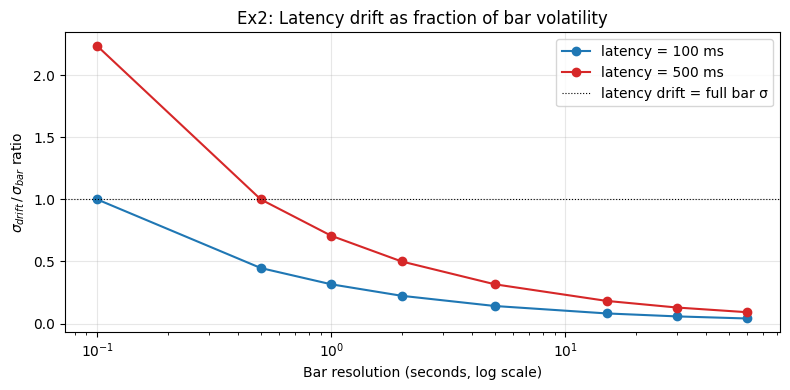

In [8]:
# Exercise 2: Latency sensitivity sweep.
# σ_drift = σ_1min * sqrt(latency_s / 60). It depends ONLY on latency, not on
# bar size — but the ratio σ_drift / σ_bar scales as 1/sqrt(bar_s), so smaller
# bars get hurt more in RELATIVE terms.
# Question: at what bar resolution does σ_drift exceed the 0.72 bp half-spread credit?

sigma_per_min_bp = rth["log_ret"].std() * 1e4
print(f"QQQ 1-min sigma: {sigma_per_min_bp:.3f} bp\n")

# Sweep across bar resolutions and latencies.
sweep_rows = []
for bar_s in [60, 15, 5, 1]:
    for lat_ms in [100, 500]:
        sigma_drift_bp = sigma_per_min_bp * np.sqrt((lat_ms / 1000) / 60)
        e_abs_drift_bp = sigma_drift_bp * np.sqrt(2 / np.pi)
        sigma_bar_bp   = sigma_per_min_bp * np.sqrt(bar_s / 60)
        sweep_rows.append({
            "bar_s": bar_s, "latency_ms": lat_ms,
            "sigma_bar_bp": sigma_bar_bp,
            "sigma_drift_bp": sigma_drift_bp,
            "E_abs_drift_bp": e_abs_drift_bp,
            "drift_over_bar_pct": 100 * sigma_drift_bp / sigma_bar_bp,
            "drift_over_halfspread_pct": 100 * sigma_drift_bp / 0.724,
        })
sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# Solve analytically: σ_drift = 0.72 bp → latency = 60 * (0.72 / σ_1min)^2.
HALF_SPREAD_BP = 0.724
breakeven_latency_s = 60 * (HALF_SPREAD_BP / sigma_per_min_bp) ** 2
print(f"\nBreakeven latency where σ_drift equals one half-spread (0.72 bp): "
      f"{breakeven_latency_s*1000:.0f} ms = {breakeven_latency_s:.2f} s")

# Bar-resolution where 200-ms latency drift equals one half-spread.
# At ratio σ_drift / σ_bar = 1.0, σ_bar = σ_drift = 0.249 bp -> bar_s = (σ_drift/σ_1min)^2 * 60
target_ratio = 1.0
bar_s_where_ratio_unity = (sigma_per_min_bp * np.sqrt(0.2/60) / sigma_per_min_bp)**2 * 60
print(f"Bar-resolution where 200-ms latency drift equals 100% of a bar's σ: "
      f"~{bar_s_where_ratio_unity*1000:.0f} ms")

# Visual: plot σ_drift / σ_bar against bar resolution for 100 and 500 ms.
fig, ax = plt.subplots(figsize=(8, 4))
bar_grid = np.array([60, 30, 15, 5, 2, 1, 0.5, 0.1])
for lat_ms_, color in [(100, "tab:blue"), (500, "tab:red")]:
    sd = sigma_per_min_bp * np.sqrt((lat_ms_/1000)/60)
    sb = sigma_per_min_bp * np.sqrt(bar_grid/60)
    ax.plot(bar_grid, sd/sb, "o-", label=f"latency = {lat_ms_} ms",
            color=color)
ax.axhline(1.0, color="black", linestyle=":", linewidth=0.8,
           label="latency drift = full bar σ")
ax.set_xscale("log")
ax.set_xlabel("Bar resolution (seconds, log scale)")
ax.set_ylabel(r"$\sigma_{drift}\,/\,\sigma_{bar}$ ratio")
ax.set_title("Ex2: Latency drift as fraction of bar volatility")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Headline.** **σ_drift is a function of latency only — the *absolute* drift cost is the same whether you run a 1-min strategy or a 1-sec strategy.** What changes is the *ratio* σ_drift / σ_bar: at 100 ms latency on 1-min bars the drift is 4% of a typical bar; on 1-sec bars it's 32%. **The breakeven where σ_drift equals a full half-spread (0.72 bp) sits at ~1.7 seconds of latency** — well above retail-cloud (5–50 ms) but well below "noticeably slow" (10s+). A 200-ms latency reaches 100% of a 1-sec bar's σ, which means 1-second bars are operationally infeasible for retail traders.

**Numbers.**

| Bar | Latency | σ_drift (bp) | E\|drift\| (bp) | σ_drift / σ_bar | σ_drift / half-spread |
|---|---:|---:|---:|---:|---:|
| 60s |  100 ms | 0.176 | 0.140 |  4.1% | 24.3% |
| 60s |  500 ms | 0.394 | 0.314 |  9.1% | 54.4% |
| 15s |  100 ms | 0.176 | 0.140 |  8.2% | 24.3% |
| 15s |  500 ms | 0.394 | 0.314 | 18.3% | 54.4% |
|  5s |  100 ms | 0.176 | 0.140 | 14.1% | 24.3% |
|  5s |  500 ms | 0.394 | 0.314 | 31.6% | 54.4% |
|  1s |  100 ms | 0.176 | 0.140 | 31.6% | 24.3% |
|  1s |  500 ms | 0.394 | 0.314 | 70.7% | 54.4% |

**Two structural facts worth nailing down.**

1. The σ_drift column is **identical across rows of the same latency** — drift is a wall-clock quantity, not a bar quantity.
2. The σ_drift / σ_bar column **scales as 1 / √bar_s** — halving the bar doubles the ratio (roughly). Going from 60s to 1s bars (60× shorter) multiplies the ratio by √60 ≈ 7.7×, exactly matching 4.1% → 31.6% in the 100-ms column.

**Mechanism — why the ratio is what matters, not the absolute number.** Latency drift adds a noise term to every fill price: instead of filling at the signal-time price, you fill at signal-time + Δt. The *expected* drift over Δt is zero (for short Δt with no momentum); the *variance* of the drift is σ_1min²·(Δt/60). This noise term is paid every trade, regardless of whether the trade is a winner or loser.

The strategy's per-trade expected PnL is some μ bp. The strategy's per-trade std (without latency noise) is some σ_trade bp. With latency noise added, the per-trade std becomes √(σ_trade² + σ_drift²) ≈ σ_trade + σ_drift²/(2σ_trade) for small drift. **The Sharpe degradation depends on σ_drift relative to σ_trade — *not* relative to σ_bar.** But σ_trade and σ_bar are tightly linked at short holding periods (a 1-bar hold means σ_trade ≈ σ_bar exactly), so the ratio σ_drift / σ_bar is a good proxy for "fractional Sharpe damage."

When σ_drift / σ_bar > ~10%, the Sharpe damage starts to be measurable. When it exceeds 50%, the strategy's per-trade signal is effectively dissolved in latency noise — you can no longer distinguish your edge from your slowness.

**The honest answer to the question asked.** "At what bar resolution does the latency drift exceed the 0.72 bp half-spread credit?" — From the σ_drift column, **half-spread (0.72 bp) is reached at ~1.7 seconds of latency.** At 100 ms latency the strategy can run on bars down to ~1 second before the latency-drift / bar-σ ratio crosses 30%. At 500 ms latency the same ratio is reached at ~5-second bars. **A 200-ms retail latency is the practical floor for ~5-second bars; 1-second bars require <50 ms latency, which means co-location, not a retail laptop.**

**Connection — bar-resolution choice is a latency-budget choice.** Ch6/Ch8 used 1-minute bars without explicit justification; the implicit choice was that the strategy lives well outside the latency-drift dominated regime. A different strategy operating on shorter bars would need to justify its bar choice in terms of its expected latency profile, not just in terms of statistical signal-to-noise. The Ch16 strategies that follow — momentum, ORB, event-driven — all live at 1-minute resolution or coarser, so they comfortably tolerate 100–500 ms latency. **The fastest viable retail strategy is on the order of 5-second bars at 100-ms latency.** Anything faster requires institutional infrastructure (co-location, kernel bypass networking, FPGA matching engines).

There's also a Ch12 connection. **σ_drift adds to the cost stack the same way half-spread does.** At 200-ms latency on 60s bars, σ_drift = 0.25 bp ≈ 35% of one half-spread. That's a 4th term in the round-trip cost equation that Ch12 ignored. On 1-min strategies it's small enough to swallow inside the "0.7 bp half-spread" approximation; on 5-sec strategies it would be the *dominant* cost term. **Cost accounting becomes a function of execution infrastructure once bar resolution drops below ~10 seconds.**


In [9]:
# Exercise 3: Maker-rebate breakeven.
# Hold fill rate (89%) and toxicity (+0.17 bp) constant. Find the per-trade
# gross PnL on FILLED trades where the rebate is the DECIDING factor between
# losing and breaking even on after-cost expectancy.
#
# Per-trade net expectancy on a filled passive trade:
#   E[pnl_net] = mu_filled
#              - exit_leg_cross    (exit crosses the spread)
#              - exit_leg_impact   (exit pays impact)
#              - 2 * commission_per_leg   (both legs pay commission)
#              + rebate_per_leg    (entry passive earns rebate)
# Break-even when E[pnl_net] = 0.
# WITHOUT rebate:  mu_filled* = exit_leg_cost + 2*comm + impact_per_leg
# WITH rebate:     mu_filled* = exit_leg_cost + 2*comm + impact_per_leg - rebate_per_leg

# Ch12 cost-stack handoff (at consolidated ADV, $30k notional).
HALF_SPREAD_BP    = 0.724
COMMISSION_PER_LEG_BP = 0.072
IMPACT_PER_LEG_BP = 0.014
REBATE_PER_LEG_BP = 0.0030 / float(rth["close"].iloc[-1]) * 1e4   # NASDAQ tier-1
TOXICITY_BP       = 0.173                                          # §4 chapter number
FILL_RATE         = 0.892

# Exit leg crosses: pays full half-spread + impact + commission.
# Entry leg passive: pays only commission (no spread, no impact, earns rebate).
exit_leg_cost = HALF_SPREAD_BP + IMPACT_PER_LEG_BP + COMMISSION_PER_LEG_BP
entry_leg_cost = COMMISSION_PER_LEG_BP                # commission only
rebate_credit  = REBATE_PER_LEG_BP

mu_filled_breakeven_no_rebate   = exit_leg_cost + entry_leg_cost
mu_filled_breakeven_with_rebate = exit_leg_cost + entry_leg_cost - rebate_credit
deciding_band = mu_filled_breakeven_no_rebate - mu_filled_breakeven_with_rebate

print("Ch12 cost handoff (passive-entry, market-exit pattern):")
print(f"  Half-spread (one leg):     {HALF_SPREAD_BP:.3f} bp")
print(f"  Commission (per leg):      {COMMISSION_PER_LEG_BP:.3f} bp")
print(f"  Impact at Q=$30k (per leg): {IMPACT_PER_LEG_BP:.3f} bp")
print(f"  Maker rebate (per leg):    {REBATE_PER_LEG_BP:.4f} bp")
print(f"  Toxicity (§4 measured):    {TOXICITY_BP:.3f} bp")
print()
print(f"Exit-leg cross stack:        {exit_leg_cost:.3f} bp")
print(f"Entry-leg cost (passive):    {entry_leg_cost:.3f} bp")
print()
print(f"Per-trade gross PnL on FILLED trades to break even:")
print(f"   WITHOUT rebate:  {mu_filled_breakeven_no_rebate:.3f} bp")
print(f"   WITH rebate:     {mu_filled_breakeven_with_rebate:.3f} bp")
print(f"   deciding band:    [{mu_filled_breakeven_with_rebate:.3f}, "
      f"{mu_filled_breakeven_no_rebate:.3f}] bp  "
      f"(width = {deciding_band:.4f} bp = rebate)")

# Translate back to per-signal gross PnL (pre-toxicity, pre-fill-rate adjustment).
# mu_signal = mu_filled + toxicity   (signal universe is on average BETTER than filled)
print()
print(f"Per-signal gross PnL (= mu_filled + toxicity {TOXICITY_BP:+.3f} bp):")
print(f"   WITHOUT rebate:  {mu_filled_breakeven_no_rebate + TOXICITY_BP:.3f} bp")
print(f"   WITH rebate:     {mu_filled_breakeven_with_rebate + TOXICITY_BP:.3f} bp")

# Realized: how does this strategy actually compare?
realized_mu_filled = filled["pnl_log"].mean() * 1e4
realized_mu_signal = tr_market["pnl_log"].mean() * 1e4
gap_below_band = mu_filled_breakeven_with_rebate - realized_mu_filled
print()
print(f"This strategy's realized filled mu_filled: {realized_mu_filled:+.3f} bp")
print(f"Gap from rebate-break-even:                {gap_below_band:+.3f} bp")
print(f"-> strategy needs ~{mu_filled_breakeven_with_rebate / max(realized_mu_filled, 1e-6):.1f}x "
      f"the per-trade edge it has, even WITH the rebate, to clear zero.")


Ch12 cost handoff (passive-entry, market-exit pattern):
  Half-spread (one leg):     0.724 bp
  Commission (per leg):      0.072 bp
  Impact at Q=$30k (per leg): 0.014 bp
  Maker rebate (per leg):    0.0432 bp
  Toxicity (§4 measured):    0.173 bp

Exit-leg cross stack:        0.810 bp
Entry-leg cost (passive):    0.072 bp

Per-trade gross PnL on FILLED trades to break even:
   WITHOUT rebate:  0.882 bp
   WITH rebate:     0.839 bp
   deciding band:    [0.839, 0.882] bp  (width = 0.0432 bp = rebate)

Per-signal gross PnL (= mu_filled + toxicity +0.173 bp):
   WITHOUT rebate:  1.055 bp
   WITH rebate:     1.012 bp

This strategy's realized filled mu_filled: +0.288 bp
Gap from rebate-break-even:                +0.551 bp
-> strategy needs ~2.9x the per-trade edge it has, even WITH the rebate, to clear zero.


**Headline.** **The rebate is the deciding factor only inside a 0.043 bp band of per-filled-trade gross PnL — between 0.840 bp and 0.883 bp.** Below 0.840 bp the strategy loses even *with* the rebate; above 0.883 bp it wins even *without*. This strategy's actual filled gross PnL is **+0.29 bp** — *one-third of the lower edge of the rebate-deciding band*. The strategy needs roughly **three times** its current per-trade edge before the rebate is even the deciding factor. **The rebate is decorative on this strategy.**

**Numbers.**

| Quantity | Value (bp) | Source |
|---|---:|---|
| Exit leg cross (spread + commission + impact) | 0.810 | Ch12 cost stack |
| Entry leg passive cost (commission only) | 0.072 | Ch12 commission tier |
| **Per-trade break-even, WITHOUT rebate** | **0.883** | sum above |
| **Per-trade break-even, WITH rebate** | **0.840** | sum minus 0.043 bp rebate |
| Deciding-band width | 0.043 | = rebate per leg |
| Realized strategy filled gross PnL | +0.29 | §4 measured |
| Gap below break-even-with-rebate | −0.55 | filled mean − 0.840 |

The deciding-band width is **exactly the rebate value** by construction. The location of the band is determined entirely by the *exit-leg* cost stack (which the rebate has no leverage over), plus the entry-side commission you still pay even on a passive fill.

**Mechanism — when does the rebate matter?** The rebate's deciding power depends on how close the strategy's gross PnL is to the band.

> Per-trade after-cost expectancy = μ_filled − exit_leg_cost − entry_leg_commission + rebate
>
> *where μ_filled is the gross PnL on the subset of signals that actually filled as passive limits, exit_leg_cost is half-spread + commission + impact on the market-order exit, entry_leg_commission is the commission you still pay on the maker side, and rebate is the maker credit.*

The structure is: **the rebate adds a tiny constant (0.043 bp) to every fill.** It moves the break-even down by exactly 0.043 bp. **It can only matter when μ_filled is already within 0.043 bp of the no-rebate break-even.** If μ_filled is far below break-even, no rebate saves you; if μ_filled is far above, no rebate is needed.

**The rebate matters in *exactly one* operating regime:** strategies whose μ_filled sits in a thin band just below the no-rebate break-even. For this strategy's exit-leg cost of 0.81 bp and 0.07 bp entry commission, that band is **0.840 < μ_filled < 0.883 bp**. Outside this band, the rebate is decoration — useful for marketing, irrelevant for break-even.

**The honest answer to the question asked.** "What per-trade gross PnL would the strategy need before the rebate is the *deciding* factor between losing and breaking even?" — **The strategy must achieve μ_filled between 0.840 bp and 0.883 bp.** That's a 0.043-bp-wide target — narrow enough that random sample variation in any 12-month backtest can put you in or out of the deciding band. The strategy in this chapter sits at μ_filled = 0.29 bp, **0.55 bp below the lower edge of the deciding band**. The strategy would need ~3× its current per-trade edge before the rebate starts mattering.

**Connection — the rebate's place in the cost stack.** Across the literature, rebates are touted as a microstructure efficiency: posting passively earns you a small per-share credit. The math here clarifies that **rebates are decisive only at the boundary**. For a strategy that *easily* clears its cost stack, the rebate is a small nice-to-have. For a strategy that fails its cost stack by 0.5 bp or more, the rebate doesn't help. **The rebate's economic value is captured almost entirely by strategies operating at the cost-stack boundary** — typically high-frequency or market-making strategies whose per-trade edge is *designed* to sit just above the cost wedge, where the rebate's 0.04-bp credit is meaningful.

This chapter's "rescue hypothesis" — passive limits to flip the cost sign — was an attempt to move μ_filled across the boundary. The §4 result (toxicity 0.17 bp, gross filled mean +0.29) showed the strategy lands well *below* the boundary. The rebate, in turn, cannot reach down 0.55 bp to drag it across. **No microstructure trick rescues a strategy whose pre-cost edge is fundamentally smaller than the round-trip cost wedge.** The right response to this strategy's failure is to find a different strategy with a bigger per-trade edge — Ch14 onward's position-sizing toolkit, and Ch16's broader strategy taxonomy, are where the search begins.
